# Optimization of CNN - TPE

In this notebook, we will optimize the hyperparameters of a CNN using the define-by-run model from Optuna.

In [1]:
# For reproducible results.
# See: 
# https://keras.io/getting_started/faq/#how-can-i-obtain-reproducible-results-using-keras-during-development

import os
os.environ['PYTHONHASHSEED'] = '0'

import numpy as np
import tensorflow as tf
import random as python_random

# The below is necessary for starting Numpy generated random numbers
# in a well-defined initial state.
np.random.seed(123)

# The below is necessary for starting core Python generated random numbers
# in a well-defined state.
python_random.seed(123)

# The below set_seed() will make random number generation
# in the TensorFlow backend have a well-defined initial state.
# For further details, see:
# https://www.tensorflow.org/api_docs/python/tf/random/set_seed
tf.random.set_seed(1234)

In [2]:
import itertools
from functools import partial

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [3]:
from keras.callbacks import ReduceLROnPlateau
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D
from keras.models import Sequential, load_model
from keras.optimizers import Adam, RMSprop

from tensorflow.keras.utils import to_categorical

In [4]:
import optuna

g:\broswer download\udemy_courses\hyperparameter_optimization_for_ml\hyperparameter-optimization\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#  Data Preparation

The dataset contains information about images, each image is a hand-written digit. The aim is to have the computer predict which digit was written by the person, automatically, by "looking" at the image. 

Each image is 28 pixels in height and 28 pixels in width (28 x 28), making a total of 784 pixels. Each pixel value is an integer between 0 and 255, indicating the darkness in a gray-scale of that pixel.

The data is stored in a dataframe where each each pixel is a column (so it is flattened and not in the 28 x 28 format). 

The data set the has 785 columns. The first column, called "label", is the digit that was drawn by the user. The rest of the columns contain the pixel-values of the associated image.

In [5]:
# Load the data

data = pd.read_csv(r"G:\broswer download\udemy_courses\hyperparameter_optimization_for_ml\hyperparameter-optimization\Section-07-Other-SMBO-Models\digit-recognizer\train.csv")

# first column is the target, the rest of the columns
# are the pixels of the image

# each row is 1 image
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# split dataset into a train and test set

X_train, X_test, y_train, y_test = train_test_split(
    data.drop(['label'], axis=1), # the images
    data['label'], # the target
    test_size = 0.1,
    random_state=0)

X_train.shape, X_test.shape

((37800, 784), (4200, 784))

Text(0, 0.5, 'Number of images')

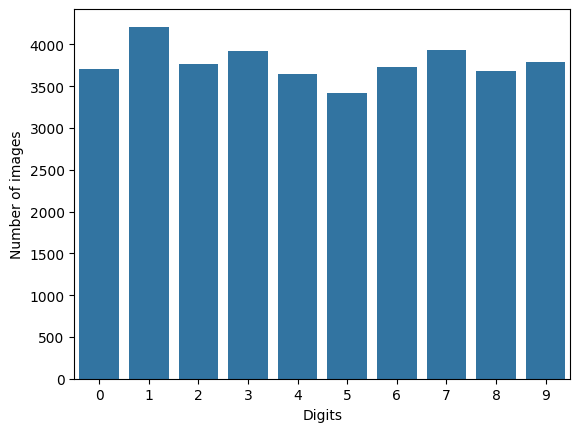

In [7]:
# number of images for each digit

g = sns.countplot(x=y_train)
plt.xlabel('Digits')
plt.ylabel('Number of images')

There are roughly the same amount of images for each of the 10 digits.

## Image re-scaling

We re-scale data for the CNN, between 0 and 1.

In [8]:
# Re-scale the data

# 255 is the maximum value a pixel can take

X_train = X_train / 255
X_test = X_test / 255

## Reshape

The images were stored in a pandas dataframe as 1-D vectors of 784 values. For a CNN with Keras, we need tensors with the following dimensions: width x height x channel. 

Thus, we reshape all data to 28 x 2 8 x 1, 3-D matrices. 

The 3rd dimension corresponds to the channel. RGB images have 3 channels. MNIST images are in gray-scale, thus they have only one channel in the 3rd dimension.

In [9]:
# Reshape image in 3 dimensions:
# height: 28px X width: 28px X channel: 1 

X_train = X_train.values.reshape(-1,28,28,1)
X_test = X_test.values.reshape(-1,28,28,1)

## Target encoding

In [10]:
# the target is 1 variable with the 9 different digits
# as values

y_train.unique()

array([2, 0, 7, 4, 3, 5, 9, 6, 8, 1], dtype=int64)

In [11]:
# For Keras, we need to create 10 dummy variables,
# one for each digit

# Encode labels to one hot vectors (ex : digit 2 -> [0,0,1,0,0,0,0,0,0,0])

y_train = to_categorical(y_train, num_classes = 10)
y_test = to_categorical(y_test, num_classes = 10)

# the new target
y_train

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

Let's print some example images.

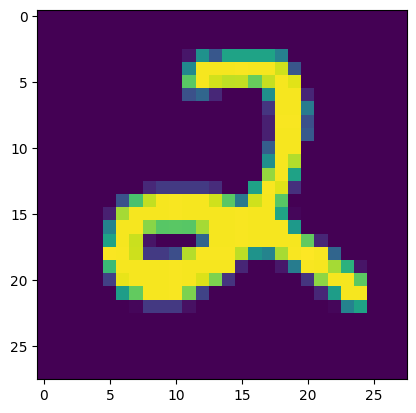

In [12]:
# Some image examples 

g = plt.imshow(X_train[0][:,:,0])

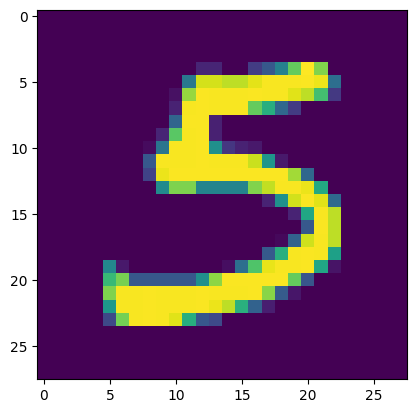

In [13]:
# Some image examples 

g = plt.imshow(X_train[10][:,:,0])

# Define-by-Run design

We create the CNN and add the sampling space for the hyperparameters as we go. This is the Desing-by-run concept.

In [14]:
# we will save the model with this name
path_best_model = 'cnn_model.keras'

# starting point for the optimization
best_accuracy = 0

In [15]:
# function to create the CNN

def objective(trial):

    # Start construction of a Keras Sequential model.
    model = Sequential()

    # Convolutional layers.

    # We add the different number of conv layers in the following loop:
    num_conv_layers = trial.suggest_int('num_conv_layers', 1, 3)

    for i in range(num_conv_layers):
        
        # NOTE: As per the below configuration, the parameters of each
        # convolutional layer will be identical.
        
        # if we want different parameters in each layer, check next
        # notebook

        model.add(Conv2D(
            filters=trial.suggest_categorical('filters', [16, 32, 64]),
            kernel_size=trial.suggest_categorical('kernel_size', [3, 5]),
            strides=trial.suggest_categorical('strides', [1, 2]),
            activation=trial.suggest_categorical(
                'activation', ['relu', 'tanh']),
            padding='same',
        ))

    # we could also optimize these parameters if we wanted:
    model.add(MaxPool2D(pool_size=2, strides=2))

    # Flatten the 4-rank output of the convolutional layers
    # to 2-rank that can be input to a fully-connected Dense layer.
    model.add(Flatten())

    # Add fully-connected Dense layers.
    # The number of layers is a hyper-parameter we want to optimize.
    # We add the different number of layers in the following loop:

    num_dense_layers = trial.suggest_int('num_dense_layers', 1, 3)

    for i in range(num_dense_layers):

        # Add the dense fully-connected layer to the model.
        # This has two hyper-parameters we want to optimize:
        # The number of nodes (neurons) and the activation function.
        model.add(Dense(
            units=trial.suggest_int('units', 5, 512),
            activation=trial.suggest_categorical(
                'activation', ['relu', 'tanh']),
        ))

    # Last fully-connected dense layer with softmax-activation
    # for use in classification.
    model.add(Dense(10, activation='softmax'))

    # Use the Adam method for training the network.
    optimizer_name = trial.suggest_categorical(
        'optimizer_name', ['Adam', 'RMSprop'])

    if optimizer_name == 'Adam':
        optimizer = Adam(learning_rate=trial.suggest_float('learning_rate',  1e-6, 1e-2))
    else:
        optimizer = RMSprop(
            learning_rate=trial.suggest_float('learning_rate',  1e-6, 1e-2),
            momentum=trial.suggest_float('momentum',  0.1, 0.9),
        )

    # In Keras we need to compile the model so it can be trained.
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # train the model
    # we use 3 epochs to be able to run the notebook in a "reasonable"
    # time. If we increase the epochs, we will have better performance
    # this could be another parameter to optimize in fact.
    history = model.fit(
        x=X_train,
        y=y_train,
        epochs=3,
        batch_size=128,
        validation_split=0.1,
    )

    # Get the classification accuracy on the validation-set
    # after the last training-epoch.
    accuracy = history.history['val_accuracy'][-1]

    # Save the model if it improves on the best-found performance.
    # We use the global keyword so we update the variable outside
    # of this function.
    global best_accuracy

    # If the classification accuracy of the saved model is improved ...
    if accuracy > best_accuracy:
        # Save the new model to harddisk.
        # Training CNNs is costly, so we want to avoid having to re-train
        # the network with the best found parameters. We save it instead
        # as we search for the best hyperparam space.
        model.save(path_best_model)

        # Update the classification accuracy.
        best_accuracy = accuracy

    # Delete the Keras model with these hyper-parameters from memory.
    del model

    # The metric to optimize
    return accuracy

In [16]:
# we need this to store the search
# we will use it in the following notebook

study_name = "cnn_study"  # unique identifier of the study.
storage_name = "sqlite:///{}.db".format(study_name)

In [17]:
study = optuna.create_study(
    direction='maximize',
    study_name=study_name,
    storage=storage_name,
    load_if_exists=True,
)

study.optimize(objective, n_trials=30)

[I 2026-08-27 00:55:09,221] Using an existing study with name 'cnn_study' instead of creating a new one.


Epoch 1/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8775 - loss: 0.3742 - val_accuracy: 0.9672 - val_loss: 0.1174
Epoch 2/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9771 - loss: 0.0767 - val_accuracy: 0.9728 - val_loss: 0.0963
Epoch 3/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9829 - loss: 0.0566 - val_accuracy: 0.9698 - val_loss: 0.1301


[I 2026-08-27 00:55:33,326] Trial 32 finished with value: 0.9698412418365479 and parameters: {'num_conv_layers': 1, 'filters': 16, 'kernel_size': 5, 'strides': 1, 'activation': 'relu', 'num_dense_layers': 3, 'units': 417, 'optimizer_name': 'Adam', 'learning_rate': 0.007263584904541297}. Best is trial 29 with value: 0.9851852059364319.


Epoch 1/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9417 - loss: 0.1830 - val_accuracy: 0.9783 - val_loss: 0.0733
Epoch 2/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9803 - loss: 0.0695 - val_accuracy: 0.9780 - val_loss: 0.0874
Epoch 3/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9857 - loss: 0.0517 - val_accuracy: 0.9796 - val_loss: 0.0798


[I 2026-08-27 00:56:01,414] Trial 33 finished with value: 0.979629635810852 and parameters: {'num_conv_layers': 2, 'filters': 16, 'kernel_size': 5, 'strides': 1, 'activation': 'relu', 'num_dense_layers': 3, 'units': 297, 'optimizer_name': 'Adam', 'learning_rate': 0.004992862400849651}. Best is trial 29 with value: 0.9851852059364319.


...

[I 2026-08-27 09:32:12,096] Trial 59 finished with value: 0.9865079522132874 and parameters: {'num_conv_layers': 2, 'filters': 64, 'kernel_size': 5, 'strides': 1, 'activation': 'relu', 'num_dense_layers': 1, 'units': 372, 'optimizer_name': 'Adam', 'learning_rate': 0.0006667648753762351}. Best is trial 59 with value: 0.9865079522132874.


Epoch 1/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 68s 249ms/step - accuracy: 0.9361 - loss: 0.2131 - val_accuracy: 0.9651 - val_loss: 0.1093
Epoch 2/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 61s 231ms/step - accuracy: 0.9828 - loss: 0.0564 - val_accuracy: 0.9794 - val_loss: 0.0680
Epoch 3/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 88s 331ms/step - accuracy: 0.9928 - loss: 0.0271 - val_accuracy: 0.9828 - val_loss: 0.0603


[I 2026-08-27 09:35:49,448] Trial 60 finished with value: 0.9828042387962341 and parameters: {'num_conv_layers': 2, 'filters': 64, 'kernel_size': 5, 'strides': 1, 'activation': 'tanh', 'num_dense_layers': 1, 'units': 366, 'optimizer_name': 'Adam', 'learning_rate': 0.0006148888610102396}. Best is trial 59 with value: 0.9865079522132874.


Epoch 1/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9151 - loss: 0.2804 - val_accuracy: 0.9701 - val_loss: 0.1039
Epoch 2/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9768 - loss: 0.0746 - val_accuracy: 0.9728 - val_loss: 0.0921
Epoch 3/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9845 - loss: 0.0470 - val_accuracy: 0.9831 - val_loss: 0.0660


[I 2026-08-27 09:36:20,781] Trial 61 finished with value: 0.9830687642097473 and parameters: {'num_conv_layers': 2, 'filters': 64, 'kernel_size': 5, 'strides': 2, 'activation': 'relu', 'num_dense_layers': 1, 'units': 344, 'optimizer_name': 'Adam', 'learning_rate': 0.0010038652564093452}. Best is trial 59 with value: 0.9865079522132874.


# Analyze results

In [18]:
study.best_params

{'num_conv_layers': 2,
 'filters': 64,
 'kernel_size': 5,
 'strides': 1,
 'activation': 'relu',
 'num_dense_layers': 1,
 'units': 372,
 'optimizer_name': 'Adam',
 'learning_rate': 0.0006667648753762351}

In [19]:
study.best_value

0.9865079522132874

Text(0, 0.5, 'Accuracy')

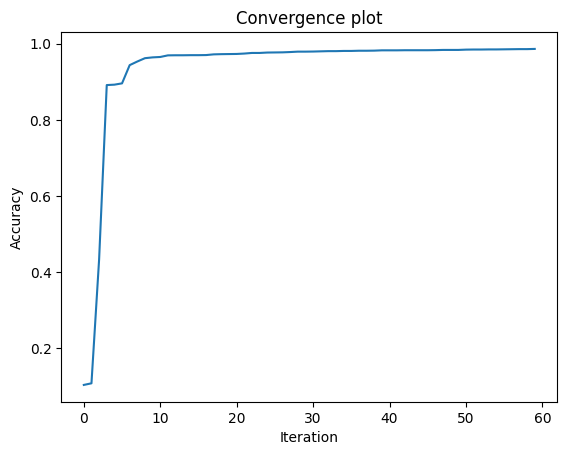

In [20]:
results = study.trials_dataframe()

results['value'].sort_values().reset_index(drop=True).plot()
plt.title('Convergence plot')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')

# Evaluate the model

In [21]:
# load best model

model = load_model(path_best_model)

In [22]:
model.summary()

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_47 (Conv2D)              │ (None, 28, 28, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 28, 28, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 372)            │     4,666,740 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 10)             │         3,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,323,796 (54.64 MB)

 Trainable params: 4,774,598 (18.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,549,198 (36.43 MB)

In [23]:
# make predictions in test set

result = model.evaluate(x=X_test,
                        y=y_test)

132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9881 - loss: 0.0470


In [24]:
# print evaluation metrics

for name, value in zip(model.metrics_names, result):
    print(name, value)

loss 0.047023698687553406
compile_metrics 0.988095223903656


## Confusion matrix

In [25]:
# Predict the values from the validation dataset
y_pred = model.predict(X_test)

# Convert predictions classes to one hot vectors 
y_pred_classes = np.argmax(y_pred, axis = 1)

# Convert validation observations to one hot vectors
y_true = np.argmax(y_test, axis = 1)

# compute the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes) 

cm

132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step


array([[419,   0,   0,   0,   0,   0,   2,   0,   1,   0],
       [  0, 467,   1,   1,   0,   0,   1,   2,   1,   0],
       [  0,   0, 405,   0,   0,   0,   1,   2,   1,   0],
       [  0,   0,   1, 421,   0,   1,   1,   2,   0,   0],
       [  1,   1,   0,   0, 425,   0,   2,   0,   0,   0],
       [  0,   0,   0,   3,   0, 376,   2,   0,   1,   0],
       [  0,   0,   0,   0,   0,   0, 412,   0,   0,   0],
       [  0,   0,   2,   0,   0,   1,   0, 466,   0,   0],
       [  0,   1,   0,   0,   0,   2,   5,   0, 376,   0],
       [  1,   0,   1,   1,   3,   0,   2,   3,   0, 383]], dtype=int64)

Text(0.5, 21.34715460257995, 'Predicted label')

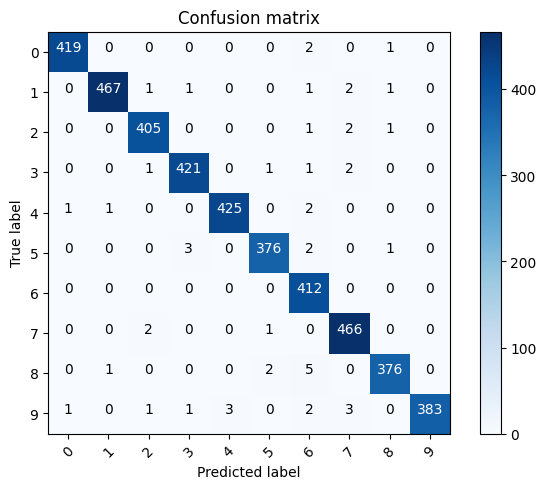

In [26]:
# let's make it more colourful
classes = 10

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix')
plt.colorbar()
tick_marks = np.arange(classes)
plt.xticks(tick_marks, range(classes), rotation=45)
plt.yticks(tick_marks, range(classes))

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center",
             color="white" if cm[i, j] > 100 else "black",
            )

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')

Here we can see that our CNN performs very well on all digits.